# Assignment 2

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import softmax
from sklearn.metrics import average_precision_score

## Problem 1

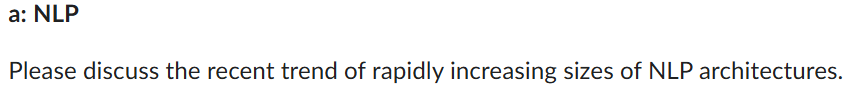

The recent trends in Natural Language Processing (NLP) have changed the way we use the computer. Chatbots are getting more and more popular, and we (users) expect them to only get better. To improve the chatbot, it comes with a cost of size. The network is becoming larger, and this might be a problem. At the moment (DEC2023) a chatgpt query cost 3Wh which translates to 36 cents, according to Medium. This is around 10 times more than a google search. Chatgpt alone consumes 0.5 million KWh pr day. In 2024, where minimizing power consumption is a huge deal, we need to consider how much better the NLP gets, when the increases in size and therefore consume more power.

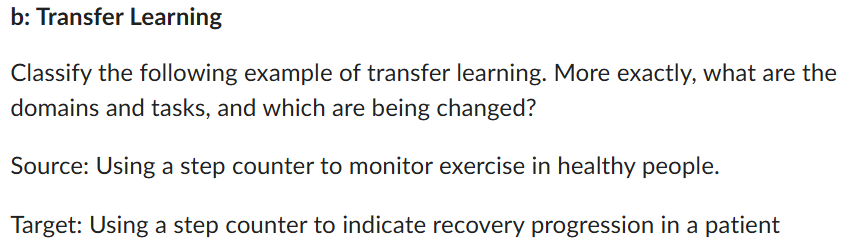

When talking about transfer learning, we often use the use the terminology of domain and task, and source and target. In this case where we want to use a step counter for two different purposes, we can say that the domain is the same D_S=D_T, since we use a step counter in both scenarios. But the tasks are different. This is an example of inductive transfer learning.

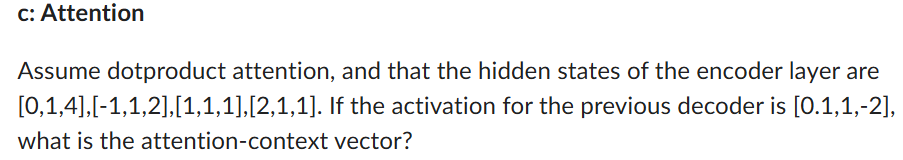

In [39]:
# Encoder hidden states
encoder_hidden_states = np.array([
    [0, 1, 4],
    [-1, 1, 2],
    [1, 1, 1],
    [2, 1, 1]
])

# Decoder activation (s_(i-1))
decoder_activation = np.array([0.1, 1, -2])

# Step 1: Calculate attention scores using dot product (a_ij = s_(i-1)^T * h_j)
scores = np.dot(encoder_hidden_states, decoder_activation)
print(f"a_ij = {scores}")

# Step 2: Apply softmax to get attention weights (alpha_ij = softmax(a_ij))
attention_weights = softmax(scores)
print(f"alpha_ij = {attention_weights}")

# Step 3: Calculate attention-context vector as weighted sum of encoder hidden states (c_i = sum(alpha_ij * h_j))
attention_context_vector = np.sum(attention_weights[:, np.newaxis] * encoder_hidden_states, axis=0)
print(f"c_i = {attention_context_vector}")

a_ij = [-7.  -3.1 -0.9 -0.8]
alpha_ij = [0.00101111 0.04995145 0.45081253 0.4982249 ]
c_i = [1.39731088 1.         1.05298479]


The attention_context_vector is approx: c_i = [1.4, 1, 1.05]

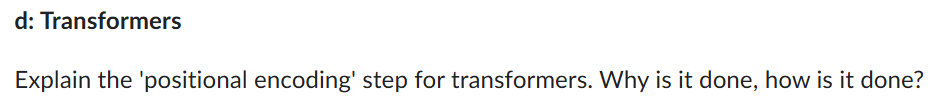

The positional_encoding function ensures that transformers remembers the order of the data. Transformers uses parallel processing, so it doesn't have a sense of order. 
The positional encoding function adds information about the position of the token in the sequence, before the sequence gets processed.

The way it works is by adding an encoding vector to each of the tokens.

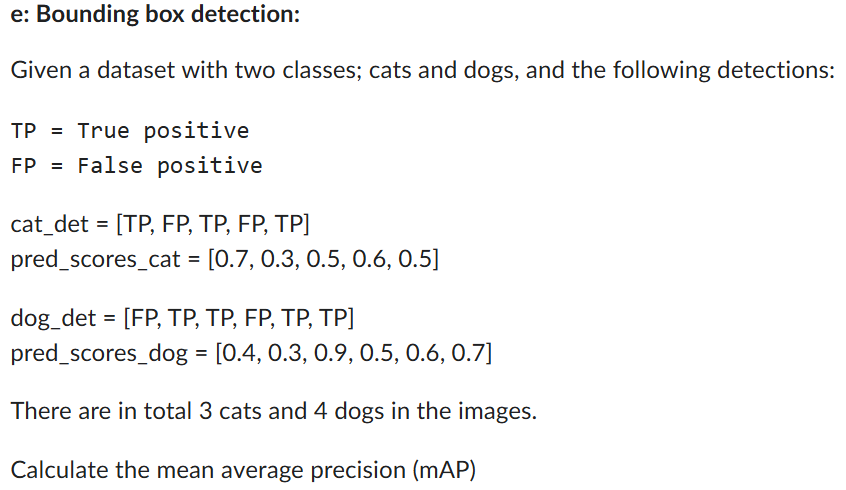

We use the procedure from slides and the formula from slides:

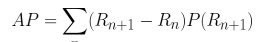

In [43]:
# Given data
cat_det = ['TP', 'FP', 'TP', 'FP', 'TP']
pred_scores_cat = [0.7, 0.3, 0.5, 0.6, 0.5]
dog_det = ['FP', 'TP', 'TP', 'FP', 'TP', 'TP']
pred_scores_dog = [0.4, 0.3, 0.9, 0.5, 0.6, 0.7]

def precision_recall(len_true, detection, prediction):
    # Sort the predictions by decreasing score
    sorted_indices = np.argsort(prediction)[::-1]
    detection = np.array(detection)[sorted_indices]
    
    # Calculate precision and recall
    tp = np.cumsum(detection == 'TP')
    fp = np.cumsum(detection == 'FP')
    precision = tp / (tp + fp)
    recall = tp / len_true
    # Calculate average precision
    ap = 0
    for i in range(len(recall) - 1):
        ap += (recall[i+1] - recall[i]) * precision[i+1]
    return precision, recall, ap

# Calculate precision, recall and average precision for cat detections
precision_cat, recall_cat, ap_cat = precision_recall(3, cat_det, pred_scores_cat)
print(f"Precision cat: {precision_cat}")
print(f"Recall cat: {recall_cat}")
print(f"Average Precision cat: {np.round(ap_cat,2)}")

# Calculate precision, recall and average precision for dog detections
precision_dog, recall_dog, ap_dog = precision_recall(4, dog_det, pred_scores_dog)
print(f"Precision dog: {precision_dog}")
print(f"Recall dog: {recall_dog}")
print(f"Average Precision dog: {np.round(ap_dog,2)}")

# Calculate mean average precision
map = (ap_cat + ap_dog) / 2
print(f"Mean Average Precision: {np.round(map,2)}")

Precision cat: [1.         0.5        0.66666667 0.75       0.6       ]
Recall cat: [0.33333333 0.33333333 0.66666667 1.         1.        ]
Average Precision cat: 0.47
Precision dog: [1.         1.         1.         0.75       0.6        0.66666667]
Recall dog: [0.25 0.5  0.75 0.75 0.75 1.  ]
Average Precision dog: 0.67
Mean Average Precision: 0.57


The map is 0.57

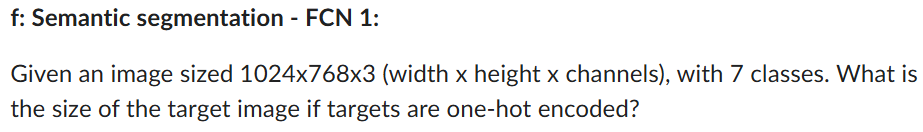

In semantic segmentation, each pixel needs to be classified. After this segmantation, we are able to create an 1024x768x1 image with the most probable classes for each pixel. 

Since each pixel has a probability to belong in each of the 7 classes, the target needs to be 1024x768xclasses = 1024x768x7.


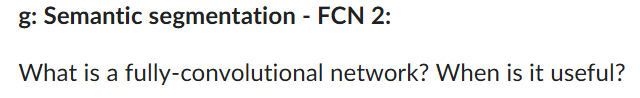

Like the name states, a fully-convolutional network (FCN) is a neural network that consists of only convolutional layers. This type of network is commonly used in computer vision tasks, such as image segmentation, where the input and output are images. 

The is usefull when you want to classify each pixel of an image. This can be usefull for many applications, where you want to divide your image into multible segments.

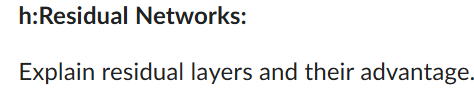

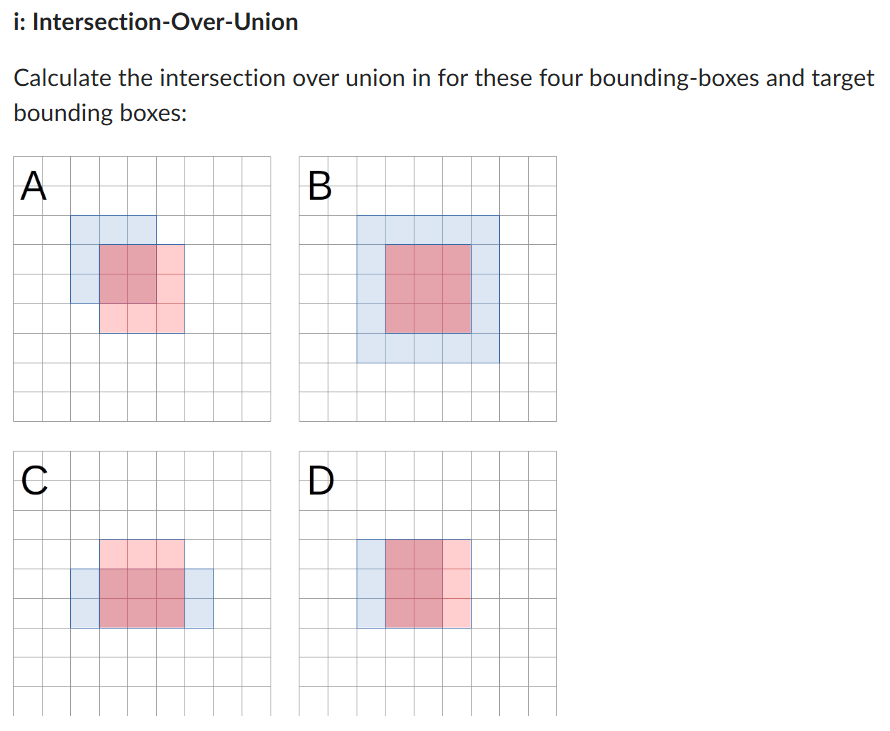


The formula for Intersection over Union (IoU) is given by:
$$
IOU = \frac{\text{Area of Intersection of two boxes}}{\text{Area of Union of two boxes}}
$$

Using this formula we can calculate the IoU of two boxes.

$$
\begin{aligned}
IoU_A = \frac{4}{2\cdot 9 - 4} = \frac{4}{14} = \frac{2}{7}\\

IoU_B = \frac{9}{5 \cdot 5} = \frac{9}{25}\\

IoU_C = \frac{6}{10+3} = \frac{6}{13} \\

IoU_D = \frac{6}{2\cdot6} = \frac{6}{12} = \frac{1}{2} \\
\end{aligned}
$$

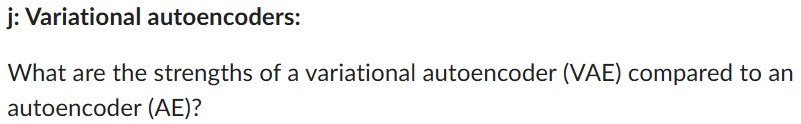

## Problem 2

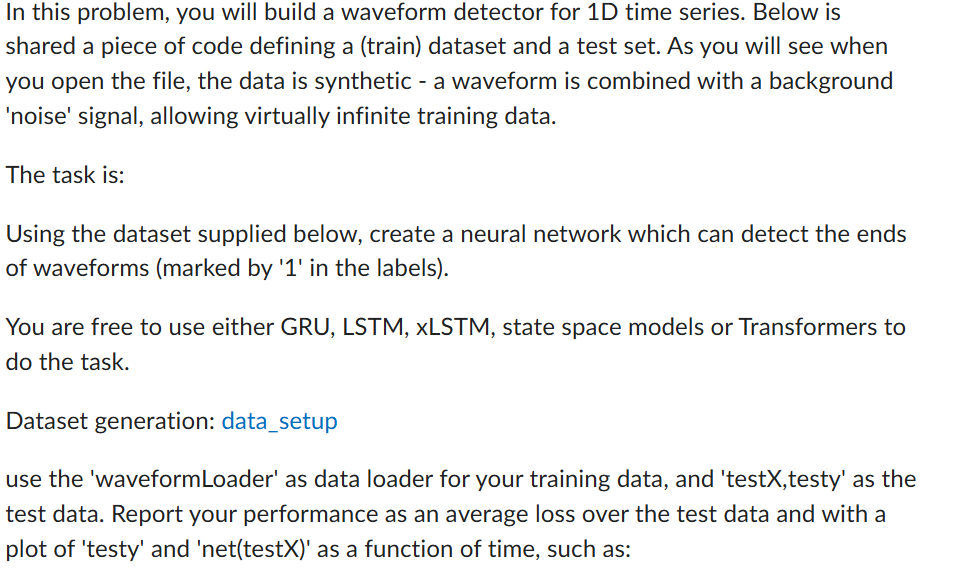
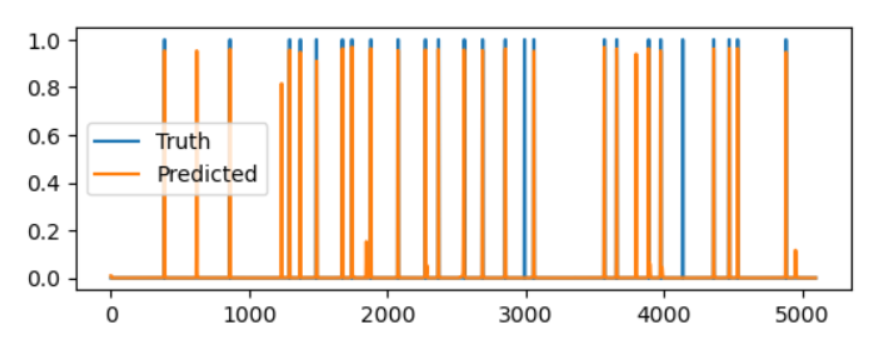

Text(0, 0.5, 'y')

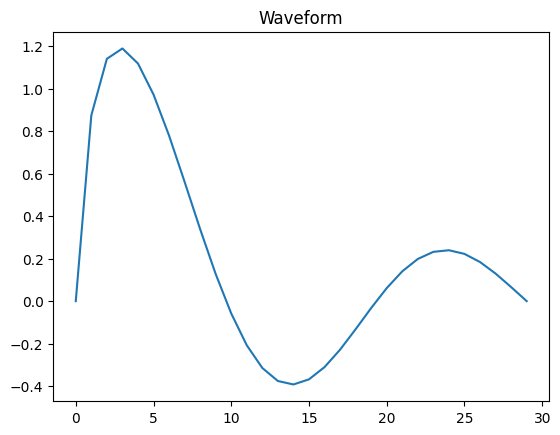

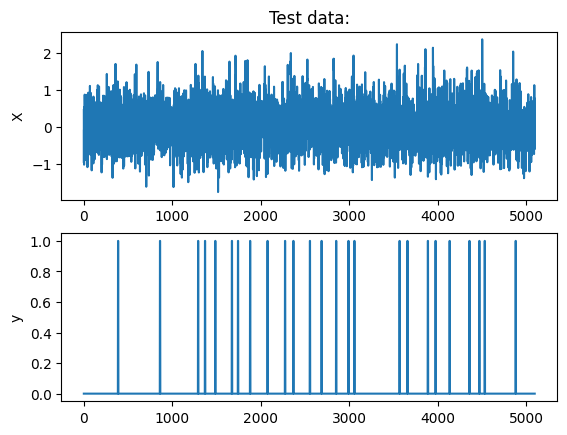

In [2]:
#%% load packages

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

#%%

#Prepare waveform data set container:
class waveFormDataset(torch.utils.data.Dataset):
    """waveFormDetectionDataset"""

    def __init__(self, waveforms, backgroundGenerator, targetRate=1):
        """
        Args:
            waveforms: array of size nxl, showing n different examples of target waveforms, length l
            backgroundGenerator: function, no input, outputs non-target signals, length L>l
        """

        if len(waveforms.shape)==0:
            waveforms=np.expand_dims(waveforms,0)

        self.ntargets=waveforms.shape[0]
        self.targets=waveforms
        self.backgroundGenerator=backgroundGenerator
        self.targetRate=targetRate

    def __len__(self):
        return 1000 #arbitrary

    def __getitem__(self, idx):
        #combines targets and backgroundGenerator. includes target in targetRate*100 percentage of outputs

        sample=self.backgroundGenerator()

        assert(len(sample)>=self.targets.shape[1])

        labels=sample*0

        if np.random.rand()<=self.targetRate:
            target=self.targets[np.random.randint(0,self.ntargets),:]
            target=torch.reshape(target,(-1,1))
            targetL=len(target)

            backgroundL=len(sample)

            endBuffer=4 #we need to ensure a bit of space at the end for placing 1-labels
            startIdx=np.random.randint(0,backgroundL-targetL-endBuffer,1)[0]
            sample[startIdx:(startIdx+targetL)]=sample[startIdx:(startIdx+targetL)]+target
            labels[startIdx+targetL+range(0,endBuffer)]=1


        return sample,labels

# %%

# setup dataset

#training:
targetL=30
waveform=np.sin(np.linspace(0,np.pi*3,targetL))/np.linspace(.2,5,targetL)
waveform=np.expand_dims(waveform,0)
waveform=torch.tensor(waveform,dtype=torch.float32)

def bgg():
    backgroundL=100
    scale=.5
    background=torch.tensor(np.random.normal(0,scale=scale,size=(backgroundL,1)),dtype=torch.float32)
    return background

wfDataset=waveFormDataset(waveform,bgg,.5)
e=wfDataset.__getitem__(1)
waveformLoader=torch.utils.data.DataLoader(wfDataset,batch_size=32)
# %%

#seed random number generator:
torch.manual_seed(1066)
np.random.seed(1066)

#test dataset:
nTest=50
testX,testy=wfDataset.__getitem__(1)

for iVal in range(nTest):
    x,y=wfDataset.__getitem__(1)
    testX=torch.cat((testX,x),0)
    testy=torch.cat((testy,y),0)


testX=torch.unsqueeze(testX,0)

plt.plot(waveform[0,:])
plt.title('Waveform')
plt.figure()
plt.subplot(2,1,1)
plt.plot(testX[0,:])
plt.ylabel('X')
plt.title('Test data:')

plt.subplot(2,1,2)
plt.plot(testy[:,0])
plt.ylabel('y')